# Bài tập về nhà Decision Tree, Random Forest


- Thực hiện các yêu cầu dưới đây với tập dữ liệu Australian credit
- Down dữ liệu tại đường link dưới đây và đặt vào folder /data
 
  https://archive.ics.uci.edu/ml/datasets/Statlog+(Australian+Credit+Approval)
    

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, ShuffleSplit, cross_val_score
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier 
from sklearn.tree import DecisionTreeClassifier 

random_state = 0


## 1. Tìm hiểu dữ liệu

In [5]:
'''
- Tìm hiểu cấu trúc data tại trang web UCI
- Down các files, đặt trong folder data/
- Chú ý:
    - Đọc mô tả dữ liệu trong file 'australian.doc'
    - Kiểm tra DecisionTree/RandomForest của Sklearn có hỗ trợ với kiểu dữ liệu được cung cấp không
'''
data_path = './australian.dat'
credit = np.genfromtxt(data_path)
print(credit)
X,y=credit[:,:-1], credit[:,-1]
print (X.shape, y.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)
print (X_train.shape, y_train.shape)

[[1.000e+00 2.208e+01 1.146e+01 ... 1.000e+02 1.213e+03 0.000e+00]
 [0.000e+00 2.267e+01 7.000e+00 ... 1.600e+02 1.000e+00 0.000e+00]
 [0.000e+00 2.958e+01 1.750e+00 ... 2.800e+02 1.000e+00 0.000e+00]
 ...
 [0.000e+00 1.883e+01 9.540e+00 ... 1.000e+02 1.000e+00 1.000e+00]
 [0.000e+00 2.742e+01 1.450e+01 ... 1.200e+02 1.200e+01 1.000e+00]
 [1.000e+00 4.100e+01 4.000e-02 ... 5.600e+02 1.000e+00 1.000e+00]]
(690, 14) (690,)
(552, 14) (552,)


## 2. Decision Tree

### 2.1. Khảo sát các giá trị khác nhau của max_depth

Text(0.5, 1.0, 'DT validation curve for max_depth')

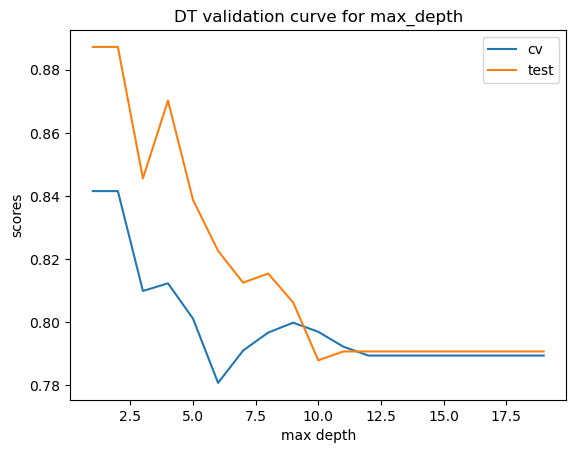

In [6]:
# code
cv_accuracies_by_depth, test_accuracies_by_depth=[],[]
max_depth_values=np.arange(1, 20)
for max_depth in max_depth_values:
    tree=DecisionTreeClassifier(random_state=random_state, max_depth=max_depth)
    val_scores=cross_val_score(estimator=tree, X=X_train, y=y_train, cv=5, scoring='f1')
    cv_accuracies_by_depth.append(val_scores.mean())

    tree.fit(X_train, y_train)
    y_pred=tree.predict(X_test)
    test_accuracies_by_depth.append(f1_score(y_test, y_pred))

plt.plot(max_depth_values, cv_accuracies_by_depth, label='cv')
plt.plot(max_depth_values, test_accuracies_by_depth, label='test')
plt.legend()
plt.xlabel('max depth')
plt.ylabel('scores')
plt.title('DT validation curve for max_depth')

### 2.2. Tìm kiếm siêu tham số

In [7]:
#code
dict_param = {
    'max_depth': [2, 3, 5, 7, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'criterion': ["gini", "entropy"]
}
# Utility functions
def grid_search(algorithm, n_jobs, dict_param):
    if algorithm == 'decision-tree':
        model = DecisionTreeClassifier()
    if algorithm == 'random-forest':
        model = RandomForestClassifier()
    classifier = GridSearchCV(estimator=model, cv=5, param_grid=dict_param,
                            n_jobs=n_jobs, scoring='f1')
    classifier.fit(X_train, y_train)
    print('Best model', end='')
    print(classifier.best_estimator_)
    return classifier.best_estimator_

def evaluate(model): 
    print("Train Accuracy :", accuracy_score(y_train, model.predict(X_train)))
    print("Train f1 score :", f1_score(y_train, model.predict(X_train)))  
    print("Train roc auc :", roc_auc_score(y_train, model.predict(X_train)))  
    print("Train Confusion Matrix:")
    print(confusion_matrix(y_train, model.predict(X_train)))
    print("-"*50)
    print("Test Accuracy :", accuracy_score(y_test, model.predict(X_test)))
    print("Test f1 score :", f1_score(y_test, model.predict(X_test)))
    print("Test roc auc :", roc_auc_score(y_test, model.predict(X_test)))  
    print("Test Confusion Matrix:")
    print(confusion_matrix(y_test, model.predict(X_test)))

def plot_learning_curve(estimator, title, label_curve, X, y, ylim=None, cv=None,
                        n_jobs=1, train_sizes=np.linspace(.1, 1.0, 5), new_plot=False,
                        idx_color=0):
    # Khởi tạo bức ảnh mới với thư viện plot lib 
    if new_plot:
        # plt.figure()
        plt.title(title)
        plt.xlabel("Training examples")
        plt.ylabel("Score")
        plt.grid()
    # chú thích nếu có 
    if ylim is not None:
        plt.ylim(*ylim)
        
    # thực hiện training model, ghi nhận các giá trị trong quá trình training 
    # cv = số fold cross validate, số phần bộ dữ liệu được chia để thực hiện training testing.
    # train_sizes = mảng tỉ lệ, các tỉ lệ được hệ thống chọn làm điểm dừng để thực hiện 1 testing 
    #  train_sizes = [0.3, 0.5] => hệ thống lấy 30 % dữ liệu để train và thực hiện test, tương tự 50 % ..
    # scoring = hàm mục tiêu để đánh giá chất lượng mô hình và vẽ lên đồ thị 
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring="f1")
    # Lấy trung bình cộng các giá trị output của các fold 
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    # thực hiện vẽ các giá trị số lên đồ thị với màu vừa được random 
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='r')
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='g')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='r',
             label=label_curve['test'])
    plt.plot(train_sizes, train_scores_mean, 'o-', color='g',
             label=label_curve['train'])

    plt.legend(loc="best")
    return plt

Best modelDecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=50)
Train Accuracy : 0.8641304347826086
Train f1 score : 0.8440748440748441
Train roc auc : 0.8613569714742735
Train Confusion Matrix:
[[274  36]
 [ 39 203]]
--------------------------------------------------
Test Accuracy : 0.855072463768116
Test f1 score : 0.8360655737704918
Test roc auc : 0.8512118018967333
Test Confusion Matrix:
[[67  6]
 [14 51]]


<module 'matplotlib.pyplot' from '/opt/miniconda3/lib/python3.13/site-packages/matplotlib/pyplot.py'>

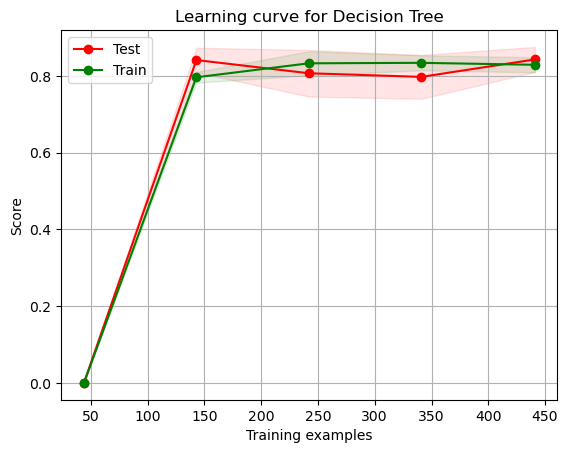

In [9]:
best_tree=grid_search('decision-tree', n_jobs=-1, dict_param=dict_param)
best_tree.fit (X_train, y_train)
evaluate(best_tree)
title='Learning curve for Decision Tree'
label_curve={'train': 'Train', 'test': 'Test'}
plot_learning_curve(estimator=best_tree, title=title, label_curve=label_curve, X=X_train, y=y_train, cv=5, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5), new_plot=True)

## 3. Random Forest

### 3.1 Khảo sát các giá trị khác nhau của n_estimators

Text(0.5, 1.0, 'Random Forest validation curve for n_estimators')

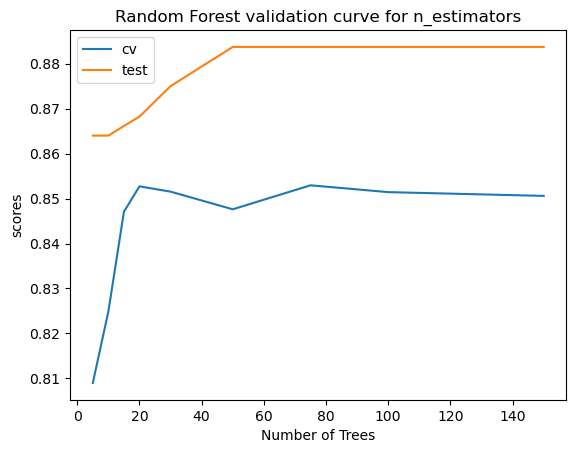

In [12]:
#code
cv_accuracies_by_n_trees, test_accuracies_by_n_trees=[],[]
num_trees=[5,10,15,20,30,50,75,100,150]
for n_tree in num_trees:
    forest=RandomForestClassifier(n_estimators=n_tree, random_state=random_state)
    val_scores=cross_val_score(estimator=forest, X=X_train, y=y_train, cv=5, scoring='f1')
    cv_accuracies_by_n_trees.append(val_scores.mean())

    forest.fit(X_train, y_train)
    y_pred=forest.predict(X_test)
    test_accuracies_by_n_trees.append(f1_score(y_test, y_pred))

plt.plot(num_trees, cv_accuracies_by_n_trees, label='cv')
plt.plot(num_trees, test_accuracies_by_n_trees, label='test')
plt.legend()
plt.xlabel('Number of Trees')
plt.ylabel('scores')
plt.title('Random Forest validation curve for n_estimators')

### 3.2 Tìm kiếm siêu tham số

Best modelRandomForestClassifier(max_depth=7, min_samples_leaf=5)
Train Accuracy : 0.927536231884058
Train f1 score : 0.9152542372881356
Train roc auc : 0.9237003465742469
Train Confusion Matrix:
[[296  14]
 [ 26 216]]
--------------------------------------------------
Test Accuracy : 0.8623188405797102
Test f1 score : 0.848
Test roc auc : 0.8597471022128557
Test Confusion Matrix:
[[66  7]
 [12 53]]


<module 'matplotlib.pyplot' from '/opt/miniconda3/lib/python3.13/site-packages/matplotlib/pyplot.py'>

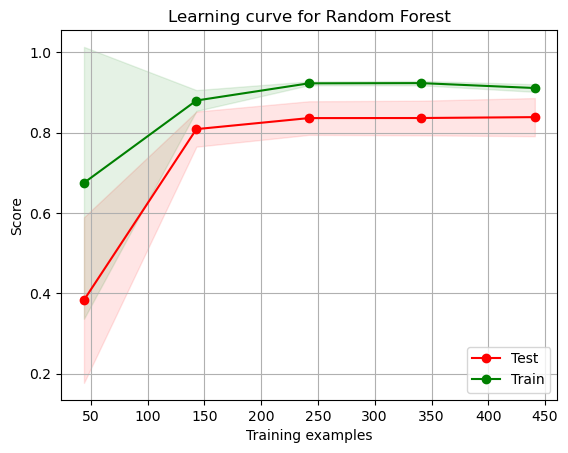

In [15]:
# code
best_forest=grid_search('random-forest', n_jobs=-1, dict_param=dict_param)
best_forest.fit (X_train, y_train)
evaluate(best_forest)
title='Learning curve for Random Forest'
label_curve={'train': 'Train', 'test': 'Test'}
plot_learning_curve(estimator=best_forest, title=title, label_curve=label_curve, X=X_train, y=y_train, cv=5, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5), new_plot=True)